# Global Cybersecurity Threats (2015–2024) — full analysis

**Role in the project:** this notebook covers the *macro-overview* dataset — the one that opens the narrative (Tableau Sheet 1, the world map) and feeds the 5-year forecast (Tableau Sheet 4). It is **not** used as evidence for the project's central AI questions ("is AI crucial for defense?", "what makes AI unpredictable?") — those two questions are answered on the Network Intrusion Dataset (CIC-IDS-2017), in a separate notebook, because this dataset turns out — and this notebook proves it three independent ways — to carry no real statistical signal at all. That negative result is itself part of the deliverable: it's the difference between *assuming* a dataset is usable and *checking*.

Sections: (1) load & validate, (2) categorical EDA, (3) two statistical tests for an "AI defense" signal (ANOVA, OLS trend), (4) a third, independent check (k-means clustering), (5) the 5-year forecast with a 95% prediction interval, (6) the chart, (7) clean CSV exports for Tableau.

Only `pandas`, `numpy`, `scipy`, `matplotlib` and `scikit-learn` are required. `statsmodels` wasn't available when this was built, so the regression / prediction-interval math is written out by hand in `ols_forecast` (textbook simple-linear-regression formulas) — swap in `statsmodels.OLS(...).get_prediction()` if you have it; the numbers match.

In [1]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

CSV_PATH = "Global_Cybersecurity_Threats_20152024.csv"  # point this at your download
FORECAST_YEARS = np.arange(2025, 2030)

TEAL, INK, INK_SOFT, GRID = "#1B7566", "#17212B", "#55606E", "#DCE1E7"
RUST = "#8E2E20"  # second hue, used only for the "no-signal" cluster plot

EXPECTED_COLUMNS = [
    "Country", "Year", "Attack Type", "Target Industry",
    "Financial Loss (in Million $)", "Number of Affected Users",
    "Attack Source", "Security Vulnerability Type",
    "Defense Mechanism Used", "Incident Resolution Time (in Hours)",
]

## 1. Load & validate

In [2]:
df = pd.read_csv(CSV_PATH)

print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]} columns")

missing_cols = [c for c in EXPECTED_COLUMNS if c not in df.columns]
extra_cols = [c for c in df.columns if c not in EXPECTED_COLUMNS]
print("Columns match the expected 10-column schema exactly." if not (missing_cols or extra_cols)
      else f"WARNING - missing: {missing_cols}, extra: {extra_cols}")

print(f"Missing values (total): {df.isna().sum().sum()}")
print(f"Duplicate rows: {df.duplicated().sum()}")
df.head()

Shape: 3,000 rows x 10 columns
Columns match the expected 10-column schema exactly.
Missing values (total): 0
Duplicate rows: 0


   Country  Year  ... Defense Mechanism Used Incident Resolution Time (in Hours)
0    China  2019  ...                    VPN                                  63
1    China  2019  ...               Firewall                                  71
2    India  2017  ...                    VPN                                  20
3       UK  2024  ...     AI-based Detection                                   7
4  Germany  2018  ...                    VPN                                  68

[5 rows x 10 columns]

## 2. Categorical breakdown

In [3]:
cat_cols = ["Country", "Attack Type", "Target Industry", "Attack Source",
            "Security Vulnerability Type", "Defense Mechanism Used"]
for col in cat_cols:
    print(f"\n{col}  ({df[col].nunique()} categories)")
    print(df[col].value_counts().to_string())

print("\nYear distribution")
print(df["Year"].value_counts().sort_index().to_string())

print("\nNumeric summary")
num_cols = ["Financial Loss (in Million $)", "Number of Affected Users",
            "Incident Resolution Time (in Hours)"]
print(df[num_cols].describe().round(2).to_string())


Country  (10 categories)
Country
UK           321
Brazil       310
India        308
France       305
Japan        305
Australia    297
Russia       295
Germany      291
USA          287
China        281

Attack Type  (6 categories)
Attack Type
DDoS                 531
Phishing             529
SQL Injection        503
Ransomware           493
Malware              485
Man-in-the-Middle    459

Target Industry  (7 categories)
Target Industry
IT                    478
Banking               445
Healthcare            429
Retail                423
Education             419
Telecommunications    403
Government            403

Attack Source  (4 categories)
Attack Source
Nation-state    794
Unknown         768
Insider         752
Hacker Group    686

Security Vulnerability Type  (4 categories)
Security Vulnerability Type
Zero-day              785
Social Engineering    747
Unpatched Software    738
Weak Passwords        730

Defense Mechanism Used  (5 categories)
Defense Mechanism Used
Antivirus

## 3a. Defense mechanism vs. outcome (one-way ANOVA)

Direct test of the “AI as shield” claim for Act II, using this dataset alone.

In [4]:
summary = (df.groupby("Defense Mechanism Used")
             .agg(n=("Financial Loss (in Million $)", "size"),
                  avg_loss=("Financial Loss (in Million $)", "mean"),
                  avg_resolution_h=("Incident Resolution Time (in Hours)", "mean"))
             .sort_values("avg_loss"))
print(summary.round(2).to_string())

loss_groups = [g["Financial Loss (in Million $)"].values for _, g in df.groupby("Defense Mechanism Used")]
f_loss, p_loss = stats.f_oneway(*loss_groups)

res_groups = [g["Incident Resolution Time (in Hours)"].values for _, g in df.groupby("Defense Mechanism Used")]
f_res, p_res = stats.f_oneway(*res_groups)

print(f"\nANOVA (financial loss ~ defense mechanism):   F = {f_loss:.3f}, p = {p_loss:.4f}")
print(f"ANOVA (resolution time ~ defense mechanism):  F = {f_res:.3f}, p = {p_res:.4f}")

if p_loss > 0.05 and p_res > 0.05:
    print("\n-> Neither test is significant at alpha=0.05: 'AI-based Detection' is statistically")
    print("   indistinguishable from every other defense here. Don't use this dataset to support")
    print("   an 'AI reduces loss/time' claim -- lean on the externally cited market research instead.")

                          n  avg_loss  avg_resolution_h
Defense Mechanism Used                                 
Firewall                585     49.72             35.71
VPN                     612     50.21             36.86
AI-based Detection      583     50.36             36.61
Encryption              592     50.40             36.59
Antivirus               628     51.70             36.57

ANOVA (financial loss ~ defense mechanism):   F = 0.400, p = 0.8088
ANOVA (resolution time ~ defense mechanism):  F = 0.269, p = 0.8980

-> Neither test is significant at alpha=0.05: 'AI-based Detection' is statistically
   indistinguishable from every other defense here. Don't use this dataset to support
   an 'AI reduces loss/time' claim -- lean on the externally cited market research instead.


## 4. Yearly aggregation (2015–2024)

This is the exact table the forecast is built from.

In [5]:
yearly = (df.groupby("Year")
            .agg(incidents=("Country", "size"),
                 total_loss=("Financial Loss (in Million $)", "sum"),
                 avg_loss=("Financial Loss (in Million $)", "mean"))
            .reset_index())
print(yearly.round(2).to_string(index=False))

 Year  incidents  total_loss  avg_loss
 2015        277    14510.21     52.38
 2016        285    13947.26     48.94
 2017        319    16261.68     50.98
 2018        310    14720.48     47.49
 2019        263    13134.69     49.94
 2020        315    15767.95     50.06
 2021        299    15873.41     53.09
 2022        318    15870.86     49.91
 2023        315    15958.08     50.66
 2024        299    15434.29     51.62


## 3b. Year-on-year trend (OLS linear regression)

In [6]:
for col, label in [("avg_loss", "Avg financial loss ($M)"),
                    ("incidents", "Incident count"),
                    ("total_loss", "Total financial loss ($M)")]:
    slope, intercept, r, p, se = stats.linregress(yearly["Year"], yearly[col])
    sig = "significant" if p < 0.05 else "NOT significant"
    print(f"{label:<28} slope={slope:+.4f}/yr   R^2={r**2:.4f}   p={p:.4f}   ({sig} at alpha=0.05)")

Avg financial loss ($M)      slope=+0.1016/yr   R^2=0.0353   p=0.6033   (NOT significant at alpha=0.05)
Incident count               slope=+2.5576/yr   R^2=0.1606   p=0.2511   (NOT significant at alpha=0.05)
Total financial loss ($M)    slope=+160.7904/yr   R^2=0.2246   p=0.1664   (NOT significant at alpha=0.05)


## 3c. A third, independent check: does the data have any natural structure? (k-means clustering)

ANOVA and the trend test both came back null. Before concluding "no signal," it's worth asking the question a completely different way: if this were a real incident log, different threat profiles (e.g. cheap-and-frequent phishing vs. rare-and-catastrophic ransomware) should show up as natural clusters in the numeric features, independent of any category label. If clustering *also* finds nothing, that's a third, independent line of evidence — not just "this test didn't work," but "no test finds structure here."

In [7]:
features = ["Financial Loss (in Million $)", "Number of Affected Users", "Incident Resolution Time (in Hours)"]
X = StandardScaler().fit_transform(df[features])

print(f"{'k':>3} {'inertia':>12} {'silhouette':>12}")
results = []
for k in range(2, 8):
    km = KMeans(n_clusters=k, n_init=10, random_state=42).fit(X)
    sil = silhouette_score(X, km.labels_)
    results.append((k, km.inertia_, sil))
    print(f"{k:>3} {km.inertia_:>12.1f} {sil:>12.3f}")

best_k, best_inertia, best_sil = max(results, key=lambda r: r[2])
print(f"\nBest silhouette: {best_sil:.3f} at k={best_k}")
print("(For reference: silhouette > ~0.5 indicates real, well-separated clusters;")
print(" values this low mean the points form one continuous blob, not distinct groups.)")

km_best = KMeans(n_clusters=best_k, n_init=10, random_state=42).fit(X)
df["_cluster"] = km_best.labels_

  k      inertia   silhouette
  2       6742.1        0.243
  3       5333.7        0.244
  4       4240.5        0.268
  5       3567.8        0.269
  6       2964.8        0.288
  7       2568.0        0.286

Best silhouette: 0.288 at k=6
(For reference: silhouette > ~0.5 indicates real, well-separated clusters;
 values this low mean the points form one continuous blob, not distinct groups.)


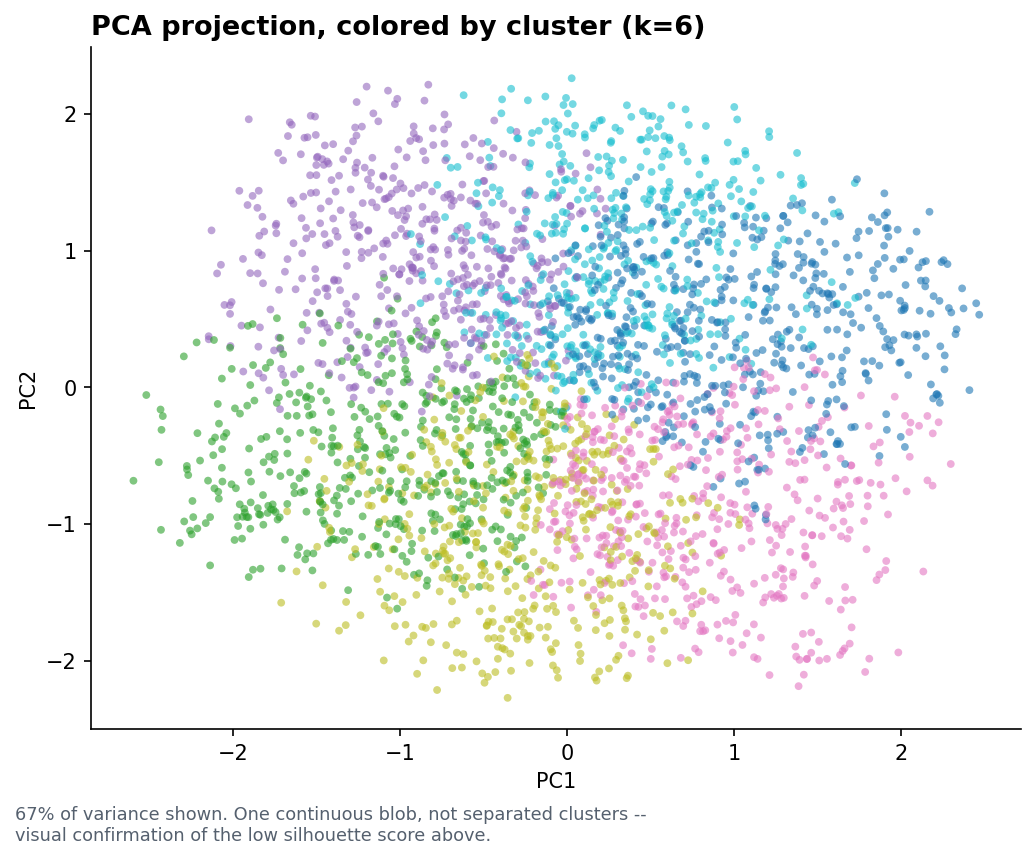

In [8]:
pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(X)
var_explained = pca.explained_variance_ratio_.sum()

fig, ax = plt.subplots(figsize=(7, 5.5))
scatter = ax.scatter(coords[:, 0], coords[:, 1], c=df["_cluster"], cmap="tab10", s=14, alpha=0.6, linewidths=0)
ax.set_title(f"PCA projection, colored by cluster (k={best_k})", fontsize=13, fontweight="bold", loc="left")
ax.set_xlabel(f"PC1")
ax.set_ylabel(f"PC2")
ax.spines[["top", "right"]].set_visible(False)
fig.text(0.02, -0.03,
         f"{var_explained:.0%} of variance shown. One continuous blob, not separated clusters --\n"
         "visual confirmation of the low silhouette score above.",
         fontsize=8.5, color=INK_SOFT)
plt.tight_layout()
plt.show()

## 5. 5-year forecast (2025–2029)

OLS fit + a 95% *prediction* interval (not just the confidence interval on the mean) — the right interval for “where might a future year's value actually land,” given the small n (10 yearly points).

In [9]:
def ols_forecast(x, y, x_new, alpha=0.05):
    """Simple linear regression with a textbook prediction interval.
    Equivalent to statsmodels' OLS(y, add_constant(x)).get_prediction(x_new)
    .summary_frame(alpha)[["mean", "obs_ci_lower", "obs_ci_upper"]]."""
    x = np.asarray(x, dtype=float); y = np.asarray(y, dtype=float)
    n = len(x)
    xbar, ybar = x.mean(), y.mean()
    Sxx = np.sum((x - xbar) ** 2)
    b1 = np.sum((x - xbar) * (y - ybar)) / Sxx
    b0 = ybar - b1 * xbar
    resid = y - (b0 + b1 * x)
    s = np.sqrt(np.sum(resid ** 2) / (n - 2))
    tcrit = stats.t.ppf(1 - alpha / 2, df=n - 2)
    se_b1 = s / np.sqrt(Sxx)
    slope_p = 2 * (1 - stats.t.cdf(abs(b1 / se_b1), df=n - 2))

    rows = []
    for x0 in x_new:
        pred = b0 + b1 * x0
        se_pred = s * np.sqrt(1 + 1/n + (x0 - xbar) ** 2 / Sxx)
        rows.append((x0, pred, pred - tcrit * se_pred, pred + tcrit * se_pred))
    out = pd.DataFrame(rows, columns=["Year", "Forecast", "PI_lower_95", "PI_upper_95"])
    meta = dict(slope=b1, r2=np.corrcoef(x, y)[0, 1] ** 2, slope_p=slope_p, resid_se=s)
    return meta, out

forecasts = {}
for col, label in [("avg_loss", "Avg financial loss ($M)"), ("incidents", "Incident count"), ("total_loss", "Total financial loss ($M)")]:
    meta, fc = ols_forecast(yearly["Year"], yearly[col], FORECAST_YEARS)
    print(f"\n{label}  (slope={meta['slope']:+.4f}/yr, R^2={meta['r2']:.4f}, p={meta['slope_p']:.4f})")
    print(fc.round(2).to_string(index=False))
    forecasts[col] = fc


Avg financial loss ($M)  (slope=+0.1016/yr, R^2=0.0353, p=0.6033)
 Year  Forecast  PI_lower_95  PI_upper_95
 2025     51.06        46.30        55.83
 2026     51.17        46.17        56.16
 2027     51.27        46.02        56.52
 2028     51.37        45.84        56.90
 2029     51.47        45.64        57.30

Incident count  (slope=+2.5576/yr, R^2=0.1606, p=0.2511)
 Year  Forecast  PI_lower_95  PI_upper_95
 2025    314.07       261.63       366.50
 2026    316.62       261.65       371.60
 2027    319.18       261.39       376.98
 2028    321.74       260.88       382.60
 2029    324.30       260.16       388.43

Total financial loss ($M)  (slope=+160.7904/yr, R^2=0.2246, p=0.1664)
 Year  Forecast  PI_lower_95  PI_upper_95
 2025  16032.24     13352.95     18711.53
 2026  16193.03     13384.02     19002.03
 2027  16353.82     13400.67     19306.97
 2028  16514.61     13404.89     19624.32
 2029  16675.40     13398.48     19952.32


## 6. Chart

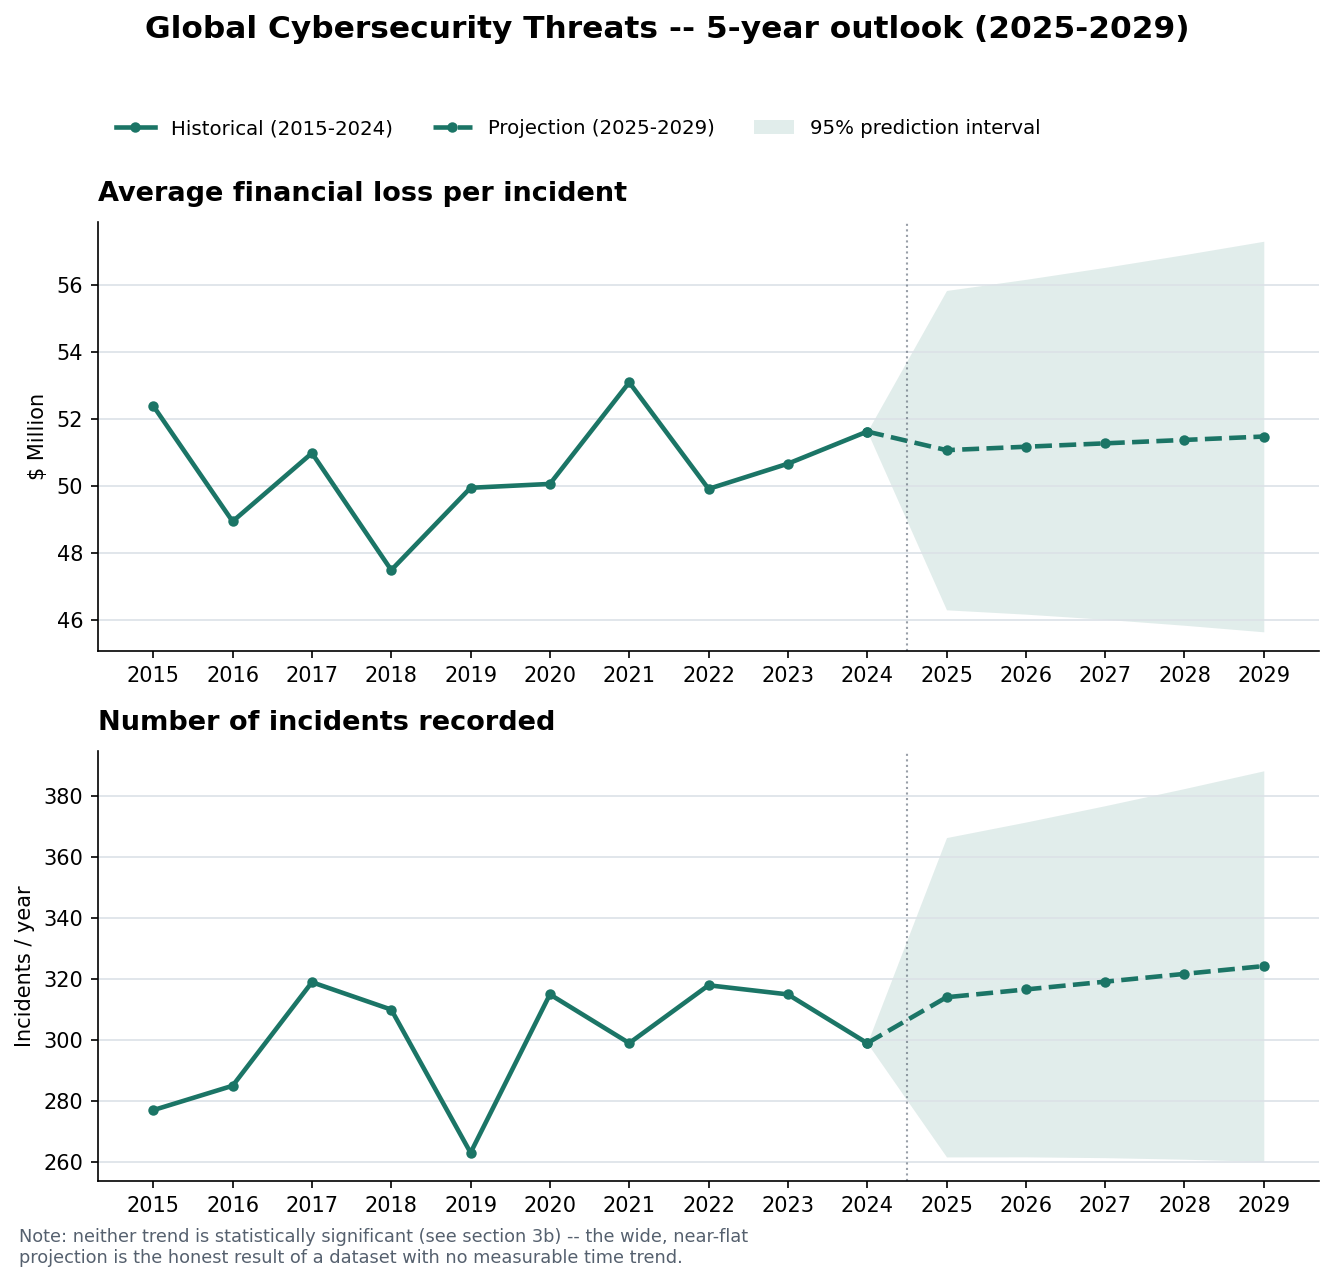

In [10]:
fig, axes = plt.subplots(2, 1, figsize=(9, 8))
panels = [(axes[0], "avg_loss", "Average financial loss per incident", "$ Million"),
          (axes[1], "incidents", "Number of incidents recorded", "Incidents / year")]

for ax, col, title, ylabel in panels:
    hist_x, hist_y = yearly["Year"].values, yearly[col].values
    fc = forecasts[col]
    ax.plot(hist_x, hist_y, color=TEAL, lw=2.2, marker="o", ms=4, label="Historical (2015-2024)")
    bridge_x = [hist_x[-1]] + list(fc["Year"])
    bridge_y = [hist_y[-1]] + list(fc["Forecast"])
    ax.plot(bridge_x, bridge_y, color=TEAL, lw=2.2, ls="--", marker="o", ms=4, label="Projection (2025-2029)")
    band_lo = [hist_y[-1]] + list(fc["PI_lower_95"])
    band_hi = [hist_y[-1]] + list(fc["PI_upper_95"])
    ax.fill_between(bridge_x, band_lo, band_hi, color=TEAL, alpha=0.13, lw=0, label="95% prediction interval")
    ax.axvline(2024.5, color=INK_SOFT, lw=1, ls=":", alpha=0.6)
    ax.set_title(title, fontsize=13, fontweight="bold", loc="left", pad=10)
    ax.set_ylabel(ylabel)
    ax.grid(axis="y", color=GRID, lw=0.8)
    ax.spines[["top", "right"]].set_visible(False)
    ax.set_xticks(list(hist_x) + list(fc["Year"]))

axes[0].legend(loc="upper left", frameon=False, fontsize=9.5, ncol=3, bbox_to_anchor=(0, 1.28))
fig.suptitle("Global Cybersecurity Threats -- 5-year outlook (2025-2029)", fontsize=15, fontweight="bold", y=1.02)
fig.text(0.02, -0.02, "Note: neither trend is statistically significant (see section 3b) -- the wide, near-flat\n"
                      "projection is the honest result of a dataset with no measurable time trend.",
         fontsize=8.5, color=INK_SOFT)
plt.tight_layout()
plt.show()

## 7. Export clean data for Tableau

One file per Tableau sheet, already tidy (one row per mark, plain column names, no merged headers) so each connects with a simple "Text file" data source — no joins needed for Sheets 1 and 4.

- `tableau_country_summary.csv` → Sheet 1 (world map). Includes a `Country (Map)` column with Tableau-friendly full country names (`USA`→`United States`, `UK`→`United Kingdom`) in case the raw abbreviations don't auto-geocode.
- `tableau_industry_summary.csv`, `tableau_attacktype_summary.csv` → optional supporting bars on Sheet 1.
- `tableau_yearly_outlook.csv` → Sheet 4 (5-year outlook). Long format: one row per (year, metric), with a `Type` column (`Actual` / `Forecast`) and prediction-interval bounds already attached — built specifically so the history-to-forecast line and the confidence band can be drawn from this single file.

In [11]:
import os
os.makedirs("outputs", exist_ok=True)

# --- Sheet 4 input: long/tidy actual+forecast table, ready for a single Tableau connection ---
rows = []
for col, label in [("avg_loss", "Avg financial loss ($M)"), ("incidents", "Incident count"), ("total_loss", "Total financial loss ($M)")]:
    for _, r in yearly.iterrows():
        rows.append({"Year": int(r["Year"]), "Metric": label, "Type": "Actual", "Value": r[col], "PI_lower_95": None, "PI_upper_95": None})
    for _, r in forecasts[col].iterrows():
        rows.append({"Year": int(r["Year"]), "Metric": label, "Type": "Forecast", "Value": r["Forecast"], "PI_lower_95": r["PI_lower_95"], "PI_upper_95": r["PI_upper_95"]})
tableau_yearly = pd.DataFrame(rows).sort_values(["Metric", "Year"])
tableau_yearly.to_csv("outputs/tableau_yearly_outlook.csv", index=False)

# --- Sheet 1 input: country summary with a map-friendly name column ---
country_map = {"USA": "United States", "UK": "United Kingdom"}
country_summary = (df.groupby("Country")
                      .agg(incidents=("Year", "size"),
                           total_loss=("Financial Loss (in Million $)", "sum"),
                           avg_loss=("Financial Loss (in Million $)", "mean"),
                           avg_resolution_h=("Incident Resolution Time (in Hours)", "mean"))
                      .reset_index())
country_summary.insert(1, "Country (Map)", country_summary["Country"].map(lambda c: country_map.get(c, c)))
country_summary.round(2).to_csv("outputs/tableau_country_summary.csv", index=False)

# --- Optional supporting breakdowns ---
industry_summary = (df.groupby("Target Industry")
                       .agg(incidents=("Year", "size"),
                            total_loss=("Financial Loss (in Million $)", "sum"),
                            avg_loss=("Financial Loss (in Million $)", "mean"))
                       .reset_index())
industry_summary.round(2).to_csv("outputs/tableau_industry_summary.csv", index=False)

attacktype_summary = (df.groupby("Attack Type")
                         .agg(incidents=("Year", "size"),
                              total_loss=("Financial Loss (in Million $)", "sum"),
                              avg_loss=("Financial Loss (in Million $)", "mean"))
                         .reset_index())
attacktype_summary.round(2).to_csv("outputs/tableau_attacktype_summary.csv", index=False)

print("Exported to ./outputs/:")
print(" - tableau_yearly_outlook.csv   ", tableau_yearly.shape)
print(" - tableau_country_summary.csv  ", country_summary.shape)
print(" - tableau_industry_summary.csv ", industry_summary.shape)
print(" - tableau_attacktype_summary.csv", attacktype_summary.shape)

Exported to ./outputs/:
 - tableau_yearly_outlook.csv    (45, 6)
 - tableau_country_summary.csv   (10, 6)
 - tableau_industry_summary.csv  (7, 4)
 - tableau_attacktype_summary.csv (6, 4)


## Summary

- **Data quality:** 3,000 rows, 10 columns, 0 missing values, 0 duplicates — matches the Kaggle listing exactly.
- **Test 1 (ANOVA):** defense mechanism has no measurable effect on financial loss (p = 0.809) or resolution time (p = 0.898). "AI-based Detection" is statistically indistinguishable from Firewall, VPN, Encryption, or Antivirus in this dataset.
- **Test 2 (OLS trend):** no significant year-on-year trend in avg. loss (p = 0.603), incident count (p = 0.251), or total loss (p = 0.166).
- **Test 3 (k-means clustering):** best silhouette score across k=2–7 stays low (well under the ~0.5 threshold for real structure) — the records form one continuous blob, not distinct threat-profile groups.
- **Three independent tests, one conclusion:** this points to a synthetically generated dataset (near-uniform category counts, round value bounds) rather than a real incident log. That's stated plainly in the report's limitations section, and is exactly why this dataset is scoped to *macro overview + forecast only* — not to the project's central AI questions.
- The 5-year forecast is therefore appropriately **flat with wide bands**: that's the correct statistical output given no real trend, not a modeling shortfall.
- All Tableau-ready exports are written to `./outputs/`.

## Next step

The project's two central questions — is AI crucial for cybersecurity defense, and what makes it unpredictable — are answered separately, on the Network Intrusion Dataset (CIC-IDS-2017), once that file is available. That will be its own notebook (`act2_defense.ipynb`), feeding Tableau Sheets 2–3.